# Tarea 2: Predicción de redshift fotométrico con métodos de ensamble

## Contexto

El redshift de una galaxia es una cantidad fundamental para estudiar distancias cosmológicas y evolución de galaxias. Idealmente, el redshift se mide mediante espectroscopía, pero obtener espectros para grandes muestras puede ser costoso en tiempo de observación.

Una alternativa ampliamente usada en astronomía es estimar redshifts fotométricos a partir de magnitudes medidas en distintos filtros. En esta actividad trabajaremos con un catálogo de galaxias que contiene fotometría multibanda y redshifts espectroscópicos de referencia. El objetivo será entrenar modelos de machine learning capaces de predecir el redshift usando información fotométrica.

La actividad se plantea como una competencia tipo **Kaggle**: cada grupo entrenará sus modelos con un conjunto de entrenamiento y deberá generar predicciones para un conjunto de test oculto. El ranking final se calculará usando el MSE sobre ese conjunto de test.

A diferencia del notebook que hicimos en clase (donde el dataset ya venía preparado), acá van a recibir el catálogo sin procesar. Van a tener que aplicar tú mismo/a las herramientas de diagnóstico que practicamos  (limpieza de datos, elección de modelo, optimización de hiperparámetros, comparación de criterios de feature importance) sin que nadie te diga de antemano qué decisiones tomar.

---

## Objetivo

Entrenar, comparar y optimizar modelos de regresión basados en árboles y métodos de ensamble para predecir el redshift de galaxias.

El criterio principal de evaluación será el error cuadrático medio:

$$
MSE = \frac{1}{N}\sum_i (z_{{\rm pred},i} - z_{{\rm true},i})^2
$$

El objetivo práctico será obtener el menor MSE posible en el conjunto de test oculto.

---

## Datos

Se entregarán tres archivos:

1. `train_redshift.csv`: contiene las variables fotométricas y el redshift de referencia.
2. `test_redshift.csv`: contiene las mismas variables fotométricas, pero no incluye el redshift.
3. `sample_submission.csv`: muestra el formato esperado para la entrega de predicciones.

El archivo de entrenamiento contiene magnitudes corregidas por apertura en distintos filtros. El redshift de referencia está en la columna: $z_{\rm helio}$

En el archivo de test, esta columna no estará disponible.

---

## Instrucciones generales

Deben desarrollar un notebook reproducible en Python que incluya:

1. Exploración inicial del conjunto de entrenamiento.
2. Preparación de los datos para modelamiento.
3. Construcción o selección de variables predictoras.
4. Separación interna entre entrenamiento y validación, o uso de validación cruzada.
5. Entrenamiento de un modelo baseline con `DecisionTreeRegressor`.
6. Entrenamiento de algún método de ensamble, por ejemplo:

   * `RandomForestRegressor`
   * `ExtraTreesRegressor`
   * `GradientBoostingRegressor`
   * `HistGradientBoostingRegressor`
   * otro método justificado.
7. Optimización de hiperparámetros (puede usar GridSearchCV, RandomizedSearchCV, Optuna, etc)
8. Comparación de modelos usando MSE.
9. Selección del modelo final.
10. Generación de predicciones para `test_redshift.csv`.

El catálogo entregado no está completamente procesado. Parte del trabajo consiste en revisar valores faltantes, valores anómalos y decidir qué variables utilizar o construir. 

El conjunto de test no contiene el redshift verdadero. Por lo tanto, no puede ser usado para evaluar ni ajustar modelos. La selección de modelos e hiperparámetros debe realizarse usando únicamente el conjunto de entrenamiento. Pueden crear un conjunto de validación interno (a partir del set de entrenamiento) para la optimización de hiperparámetros, pero el ranking final se calculará de forma ciega, evaluando sus predicciones directamente sobre test_redshift.csv

---

## Entrega de predicciones

Cada grupo debe entregar un archivo llamado:

```text
predicciones.csv
```

con exactamente dos columnas:

| objno_deep2 | z_pred |
| ----------- | ------ |
|             |        |
|             |        |
|             |        |

La columna `objno_deep2` debe coincidir con los identificadores del archivo `test_redshift.csv`.

La columna `z_pred` debe contener el redshift predicho por el modelo final.

El archivo debe tener una predicción para cada objeto del conjunto de test.

El archivo `sample_submission.csv` muestra el formato exacto que debe tener la entrega final. Deben reemplazar los valores de la columna `z_pred` por las predicciones de su modelo, manteniendo los mismos identificadores `objno_deep2`.

---
## Métricas de evaluación

La métrica principal de la competencia será el error cuadrático medio:

$$
MSE = \frac{1}{N}\sum_i (z_{{\rm pred},i} - z_{{\rm spec},i})^2
$$

Además, deberán reportar dos métricas comúnmente usadas en estudios de redshifts fotométricos.

Primero, definimos el residuo normalizado:

$$
\Delta z_i = \frac{z_{{\rm spec},i} - z_{{\rm pred},i}}{1 + z_{{\rm spec},i}}
$$

La dispersión robusta de los residuos se calculará mediante la normalized median absolute deviation:

$$
\sigma_{\rm NMAD} = 1.48 \times {\rm median}\left(
\left| \Delta z_i - {\rm median}(\Delta z) \right|
\right)
$$

También se calculará la fracción de outliers:

$$
\eta = \frac{N_{\rm outliers}}{N}
$$

donde se considera outlier a todo objeto que cumple:

$$
\frac{|z_{\rm spec} - z_{\rm pred}|}{1 + z_{\rm spec}} > 0.15
$$

El ranking de la competencia se calculará usando el MSE sobre el conjunto de test oculto. Sin embargo, en el notebook deben reportar e interpretar las tres métricas: MSE, $\sigma_{\rm NMAD}$ y $\eta$.



## Resultado esperado en el notebook

El notebook debe incluir una tabla resumen similar a la siguiente:

| Modelo        | Features usadas | Hiperparámetros principales | MSE train | MSE validación |
| ------------- | --------------- | --------------------------- | --------- | -------------- |
| Decision Tree |                 |                             |           |                |
| Ensemble      |                 |                             |           |                |

Además, deben incluir:

* un gráfico de $z_{\rm true}$ vs. $z_{\rm pred}$ usando datos de validación
* un análisis de los errores del modelo
* un análisis de las métricas obtenidas
* una discusión sobre las variables más relevantes
* una conclusión justificando el modelo final escogido

---

## Preguntas finales
Respondan brevemente al final del notebook. En todas las preguntas, la respuesta debe apoyarse en gráficos o números específicos de su propio notebook, no en generalidades.

**Sobre la comparación de modelos:**

1. ¿Qué modelo obtuvo el menor MSE en validación?
2. ¿Ese modelo fue elegido como modelo final? Justifiquen.
3. ¿Qué diferencias observaron entre un árbol individual y los métodos de ensamble?

**Sobre las variables:**

4. ¿Qué variables parecen ser más importantes para predecir el redshift?
5. Calculen la importancia de variables con al menos dos criterios distintos (por ejemplo, MDI y permutation importance). ¿Coinciden en el ranking? Si no coinciden, ¿a qué atribuyen la diferencia?

**Sobre los errores del modelo:**

6. ¿En qué rangos de redshift falla más el modelo?
7. En el notebook de clase vimos que los métodos basados en árboles tienden a "estrechar" la distribución de predicciones (sobreestiman z bajos, subestiman z altos). ¿Observan este mismo efecto en su propio scatter $z_{\rm true}$
 vs. $z_{\rm pred}$? ¿En qué rango es más pronunciado, y coincide con una menor cantidad de galaxias de entrenamiento en ese rango?
8. Si usaron oob_score en algún modelo, comparen ese valor con el de su validación cruzada. ¿Son consistentes? ¿Qué les dice eso sobre la confiabilidad de OOB para este dataset en particular?

**Sobre el proceso:**

9. ¿Qué posibles fuentes de error o sesgo puede tener este enfoque?
10. ¿Qué decisión metodológica tuvo mayor impacto en el resultado final?
11. ¿El modelo con menor MSE es necesariamente el mejor modelo desde el punto de vista científico? Justifiquen.


---

## Restricciones importantes

No se permite usar información externa al archivo entregado para predecir el redshift del conjunto de test.

No se debe modificar manualmente el archivo de predicciones para objetos individuales.

No se debe usar el conjunto de test para ajustar hiperparámetros ni tomar decisiones de modelamiento. El test oculto se usará solo para la evaluación final.

---

## Entregables

Cada grupo debe entregar:

1. Notebook reproducible en Python.
2. Archivo `predicciones.csv` con las predicciones para el conjunto de test.
3. Breve conclusión final dentro del notebook.

La evaluación considerará tanto el desempeño predictivo como la calidad del procedimiento. El notebook debe ser claro y explicativo del proceso.  El ranking se calculará usando el MSE sobre el conjunto de test oculto, pero la nota no dependerá únicamente del ranking.



# Solución 

Integrantes: Cristobal Castro Leon y Tomas Cortes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Cargo los conjuntos de datos
train_df = pd.read_csv('train_redshift.csv')
test_df  = pd.read_csv('test_redshift.csv')

In [3]:
# Exploración inicial
train_df.info()
display(train_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19057 entries, 0 to 19056
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   objno_deep2    19057 non-null  int64  
 1   ra_deep2       19057 non-null  float64
 2   dec_deep2      19057 non-null  float64
 3   zquality       19057 non-null  int64  
 4   u_apercor      19057 non-null  float64
 5   g_apercor      19057 non-null  float64
 6   r_apercor      19057 non-null  float64
 7   i_apercor      19057 non-null  float64
 8   i2_apercor     19057 non-null  float64
 9   z_apercor      19057 non-null  float64
 10  flag_cfhtls    19057 non-null  int64  
 11  cfhtls_source  19057 non-null  int64  
 12  subaru_source  19057 non-null  int64  
 13  zhelio         19057 non-null  float64
dtypes: float64(9), int64(5)
memory usage: 2.0 MB


,objno_deep2,ra_deep2,dec_deep2,zquality,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor,flag_cfhtls,cfhtls_source,subaru_source,zhelio
count,1.905700e+04,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000
mean,1.250061e+07,214.775328,52.802919,3.102902,23.072000,22.072399,21.474566,21.037788,-22.943618,20.808852,22.200714,-1.924227,-47.986567,0.714946
std,9.721234e+05,0.601017,0.415641,1.313585,21.588971,20.738837,20.670669,20.667991,59.776041,20.659574,76.125181,14.914514,49.629275,0.417994
min,1.100167e+07,213.473160,51.929113,-2.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-0.078525
25%,1.200843e+07,214.310464,52.476931,2.000000,23.671897,23.237811,22.598163,22.014806,-99.000000,21.711408,0.000000,0.000000,-99.000000,0.396693
50%,1.300380e+07,214.782577,52.810978,4.000000,24.323693,23.911843,23.415690,22.912288,21.885385,22.634205,0.000000,0.000000,0.000000,0.688533
75%,1.304796e+07,215.223139,53.111788,4.000000,25.003003,24.439543,23.896741,23.498121,23.242554,23.295065,0.000000,1.000000,0.000000,0.979685
max,1.410175e+07,216.098062,53.694992,4.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,253.000000,1.000000,1.000000,4.500611


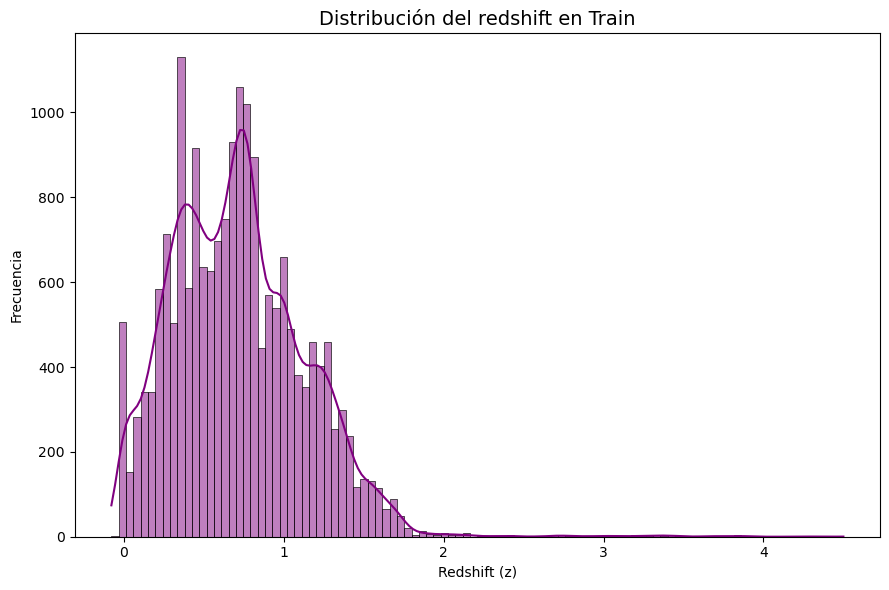

In [4]:
# Columnas de magnitudes
mag_cols = ['u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'i2_apercor', 'z_apercor']
target_col = 'zhelio'


#Limpieza: reemplazo los datos raros por NaN
datos_anomalos= [-99,99]

def limpiar_datos(df):
    """Reemplaza los datos de no medido por NaN, solo en las magnitudes"""
    d = df.copy()
    d[mag_cols] = d[mag_cols].replace(datos_anomalos, np.nan)
    return d

train_df_clean = limpiar_datos(train_df)
test_df_clean  = limpiar_datos(test_df)

# El objetivo es predecir el redshift, si una galaxia no tuviera redshift de referencia, no sirve para entrenar
if target_col in train_df_clean.columns:
    train_df_clean = train_df_clean.dropna(subset=[target_col])


#Visualizacion 
fig, ax = plt.subplots(figsize=(9,6))
sns.histplot(train_df_clean[target_col], bins=100, kde=True, color='purple')
ax.set_title(r'Distribución del redshift en Train', fontsize=14)
ax.set_xlabel('Redshift (z)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()


In [5]:
#Cuantos nans hay en cada columna
print(train_df_clean[mag_cols].isnull().sum())

u_apercor      835
g_apercor      724
r_apercor      721
i_apercor      725
i2_apercor    7349
z_apercor      726
dtype: int64


In [6]:
#Exploramos los zquiality de los datos 
#Decidimos dejar todos los datos aunque tengan zquiality bajos

resumen_zq = train_df_clean.groupby('zquality')[target_col].agg(['count', 'mean', 'std']).round(4)
display(resumen_zq)

frac_baja = (train_df_clean['zquality'] < 3).mean()
print(f"\nFracción con zquality<3 en TRAIN: {frac_baja:.1%}")

,count,mean,std
zquality,,,
-2,230,0.4130,0.5282
-1,144,-0.0003,0.0007
0,71,0.9412,0.6232
1,2556,0.6494,0.5233
2,2577,0.7582,0.5228
3,1890,0.8519,0.4082
4,11589,0.7109,0.3439



Fracción con zquality<3 en TRAIN: 29.3%


## 2–3 Preparación de datos y construcción de variables

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer


X_raw = train_df_clean[mag_cols].copy()
y = train_df_clean[target_col].copy()


# Reemplazamos los nans con la mediana del train
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X_raw), columns=mag_cols, index=X_raw.index)

#construimos los colores
bandas_estandar = ['u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'z_apercor']

def agregar_colores(Xi):
    """Agrega colores u-g, g-r, r-i, i-z e i2-z sobre un DataFrame de magnitudes imputadas""" #Notamos que i2_apercor tiene muchos nans, dejamso el color i2-z y despues vamos a ver si importancia mas adelante
    Xi = Xi.copy()
    for b1, b2 in zip(bandas_estandar[:-1], bandas_estandar[1:]):
        nombre = f'{b1.split("_")[0]}-{b2.split("_")[0]}'
        Xi[nombre] = Xi[b1] - Xi[b2]
    Xi['i2-z'] = Xi['i2_apercor'] - Xi['z_apercor']
    return Xi

X = agregar_colores(X)
feature_names = X.columns.tolist()
print(f"Features finales ({len(feature_names)}): {feature_names}")


#Dividimos 80% Train y 20% Test
RANDOM_STATE=27
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)

Features finales (11): ['u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'i2_apercor', 'z_apercor', 'u-g', 'g-r', 'r-i', 'i-z', 'i2-z']


## 4–6 Modelo baseline y métodos de ensamble

In [8]:
from sklearn.metrics import mean_squared_error

#primero definimos las metricas que calcularé para los modelos
def calcular_metricas(y_true, y_pred):
    """Devuelve (MSE, sigma_NMAD, eta) según las definiciones del enunciado."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mse = mean_squared_error(y_true, y_pred)
    delta_z = (y_true - y_pred) / (1 + y_true) #residuo normalizado
    med = np.median(delta_z)
    sigma_nmad = 1.48 * np.median(np.abs(delta_z - med)) #dispersión robusta
    eta = np.mean(np.abs(delta_z) > 0.15)#fracción de outliers
    return mse, sigma_nmad, eta


In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

#Modelos que usaremos
tree_model = DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)
rf_model   = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,random_state=RANDOM_STATE, oob_score=True)
hgb_model  = HistGradientBoostingRegressor(max_iter=100, random_state=RANDOM_STATE)

modelos = {"Decision Tree": tree_model, "Random Forest": rf_model, "HistGradientBoosting": hgb_model}


#Entreno los modelos y les calculo sus metricas
resultados = []
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    mse_train = mean_squared_error(y_train, modelo.predict(X_train))
    mse_val, nmad_val, eta_val = calcular_metricas(y_val, modelo.predict(X_val))
    resultados.append({"Modelo": nombre, "MSE Train": mse_train, "MSE Validación": mse_val,"σ_NMAD Val": nmad_val, "Outliers (η) Val": eta_val})

df_resultados = pd.DataFrame(resultados)
print("Desempeño en validación:")
display(df_resultados.round(4))
print(f"\nRandom Forest OOB R² = {rf_model.oob_score_:.4f}")

Desempeño en validación:


,Modelo,MSE Train,MSE Validación,σ_NMAD Val,Outliers (η) Val
0,Decision Tree,0.0800,0.1466,0.0762,0.2594
1,Random Forest,0.0327,0.1152,0.0560,0.2579
2,HistGradientBoosting,0.0880,0.1145,0.0692,0.2636



Random Forest OOB R² = 0.3483


## 7. Optimización de hiperparámetros

Usamos `RandomizedSearchCV` (30 combinaciones, CV interna de 3 folds) sobre `HistGradientBoosting`, usando **solo** `X_train`.

In [10]:
from sklearn.model_selection import RandomizedSearchCV

# espacio de búsqueda de hiperparámetros
param_distributions = {
    'learning_rate':     [0.01, 0.05, 0.1, 0.15],
    'max_iter':          [100, 200, 300, 400],
    'max_depth':         [5, 10, 15, 20, None],
    'min_samples_leaf':  [10, 20, 50, 100],
    'l2_regularization': [0, 0.1, 1, 10],
}

# busca los mejores datos con validación cruzada y se imprimen
random_search =RandomizedSearchCV(HistGradientBoostingRegressor(random_state=RANDOM_STATE),param_distributions,n_iter=30, scoring='neg_mean_squared_error',cv=3,random_state=RANDOM_STATE)

random_search.fit(X_train, y_train)
best_hgb = random_search.best_estimator_ # Se generan predicciones usando el modelo HGB

print("\nMejores hiperparámetros:",random_search.best_params_)

mse_train_opt = mean_squared_error(y_train, best_hgb.predict(X_train)) # Se calcula para entrenamiento y validacion
mse_val_opt, nmad_val_opt, eta_val_opt = calcular_metricas(y_val, best_hgb.predict(X_val))


# Tabla
display(pd.DataFrame([{"Modelo": "HGB (Optimizado)",
                        "MSE Train": mse_train_opt,
                        "MSE Validación": mse_val_opt, 
                        "σ_NMAD Val": nmad_val_opt,
                        "Outliers (η) Val": eta_val_opt}]
                        ).round(4))



Mejores hiperparámetros: {'min_samples_leaf': 50, 'max_iter': 300, 'max_depth': 5, 'learning_rate': 0.1, 'l2_regularization': 1}


,Modelo,MSE Train,MSE Validación,σ_NMAD Val,Outliers (η) Val
0,HGB (Optimizado),0.1023,0.1139,0.0726,0.2684


Aunque el MSE Train aumentó, creo que el modelo generaliza mejor despues de optimizar los hiperparametros, por eso su MSE VAlidacion disminuyó un poco. Osea antes de la optimizacion el modelo memorizaba, por eso tenia un MSE Train muy bajo, pero no generalizaba bien despues en Validacion.

## 8. Comparación de modelos y tabla resumen

## Tabla resumen

| Modelo | Features usadas| Hiperparámetros principales                                                              | MSE train | MSE validación |
|-----------------------|---------------------|-------------------------------------------------------------------------------------------|-----------|-----------------|
| Decision Tree         | 6 mag + 5 colores   | `max_depth=10`                                                                             | 0.0800    | 0.1466          |
| Random Forest         | 6 mag + 5 colores   | `n_estimators=300, min_samples_leaf=2`                                                     | 0.0327    | 0.1152         |
| HGB (Optimizado)      | 6 mag + 5 colores   | `learning_rate=0.1, max_iter=300, max_depth=5, min_samples_leaf=50, l2_regularization=1`| 0.1023    | 0.1139          |

In [11]:
#comparamos el OOB que usamos en random forest con su CV para la pregunta 8

from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_mse = -cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
mse_oob = (1 - rf_model.oob_score_) * np.var(y_train) 
print(f"\nRF MSE OOB= {mse_oob:.4f}")
print(f"RF MSE CV 5-fold= {cv_mse.mean():.4f} ± {cv_mse.std():.4f}")


RF MSE OOB= 0.1140
RF MSE CV 5-fold= 0.1131 ± 0.0068


## Analisis de Z_pred vs Z_True

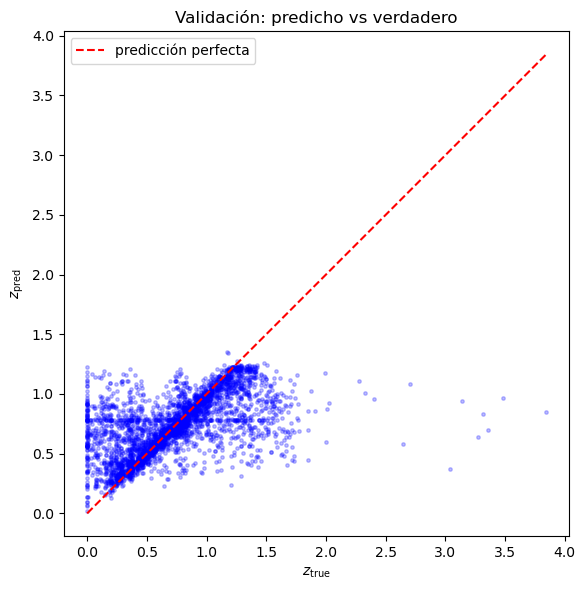

,n,z_true_medio,z_pred_medio,sesgo (pred-true),RMSE
rango,,,,,
"(0.0, 0.3]",560.0,0.181,0.532,0.350,0.450
"(0.3, 0.6]",930.0,0.446,0.550,0.104,0.201
"(0.6, 0.9]",1077.0,0.742,0.739,-0.004,0.117
"(0.9, 1.2]",657.0,1.037,0.937,-0.100,0.184
"(1.2, 1.5]",389.0,1.322,0.978,-0.344,0.428
"(1.5, 5.0]",124.0,1.767,0.825,-0.942,1.061


In [12]:
#Usamos el mejor modelo (best_hgb) sobre la validación.
y_pred_val = best_hgb.predict(X_val) 

fig, ax = plt.subplots(figsize=(8,6)) 
ax.scatter(y_val, y_pred_val, s=6, alpha=0.25,color='blue')
lims = [0,max(y_val.max(), y_pred_val.max())]
ax.plot(lims, lims,'r--',lw=1.5, label='predicción perfecta')
ax.set_xlabel(r'$z_{\rm true}$'); ax.set_ylabel(r'$z_{\rm pred}$')
ax.set_title('Validación: predicho vs verdadero')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# Sesgo por rango de redshift (efecto de estrechamiento) 
diag = pd.DataFrame({'ztrue': np.asarray(y_val), 'zpred': y_pred_val})
bins = [0, 0.3, 0.6, 0.9, 1.2, 1.5, 5]
diag['rango'] = pd.cut(diag['ztrue'], bins)
por_rango = diag.groupby('rango', observed=True).apply(lambda t: pd.Series({
    'n': len(t), 'z_true_medio': t.ztrue.mean(), 'z_pred_medio': t.zpred.mean(),
    'sesgo (pred-true)': (t.zpred - t.ztrue).mean(),
    'RMSE': np.sqrt(((t.zpred - t.ztrue) ** 2).mean())}))


display(por_rango.round(3))

## Importancia de variables

In [13]:
from sklearn.inspection import permutation_importance

# importancia de las variables(MDI)
mdi = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

# importancia de las variables(Permutación)
perm = permutation_importance(rf_model, X_val, y_val, n_repeats=10,random_state=RANDOM_STATE)
perm_imp = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False)

# compara las distintas columnas
comparacion = pd.DataFrame({'MDI': mdi, 'Permutation': perm_imp})
comparacion['rank_MDI'] = comparacion['MDI'].rank(ascending=False).astype(int)
comparacion['rank_Perm'] = comparacion['Permutation'].rank(ascending=False).astype(int)
comparacion = comparacion.loc[mdi.index]  # ordenar por MDI descendente
display(comparacion.round(4))


,MDI,Permutation,rank_MDI,rank_Perm
u-g,0.2350,0.1400,1,3
i-z,0.1512,0.1321,2,4
r-i,0.1490,0.1488,3,2
g-r,0.1451,0.1922,4,1
g_apercor,0.0653,0.0279,5,6
i2-z,0.0649,0.0357,6,5
u_apercor,0.0468,0.0111,7,9
r_apercor,0.0452,0.0208,8,7
i2_apercor,0.0359,0.0141,9,8
z_apercor,0.0325,0.0008,10,11


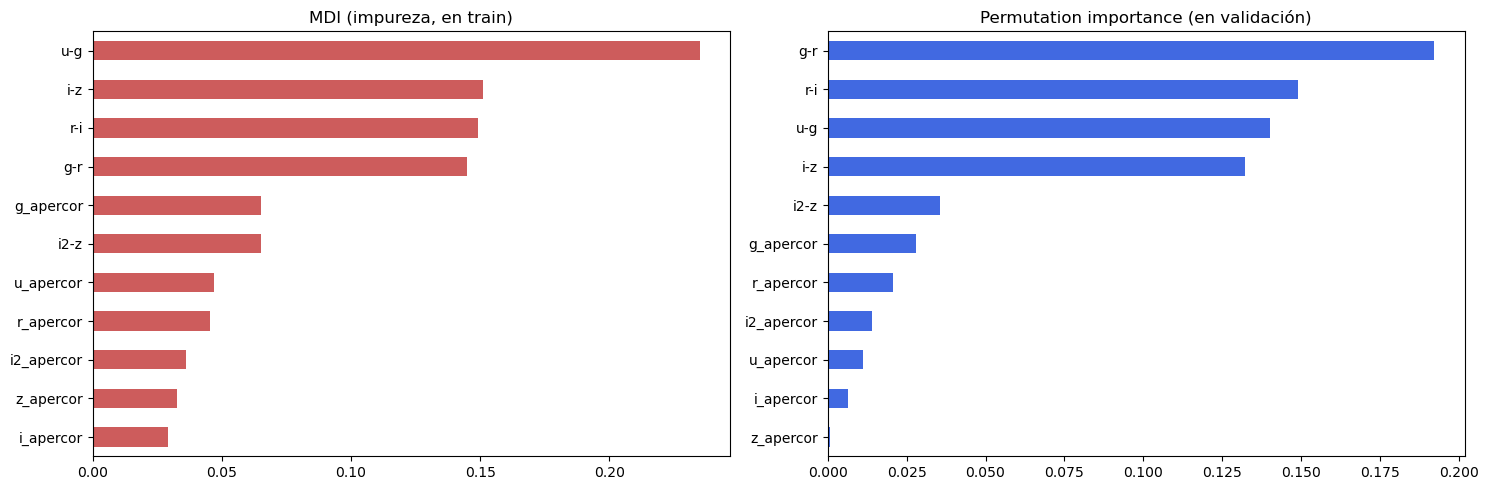

In [14]:
# Visualización de la importancia de las variables
fig, axes = plt.subplots(1,2,figsize=(15,5))
mdi.plot.barh(ax=axes[0], color='indianred') 
axes[0].invert_yaxis()
axes[0].set_title('MDI (impureza, en train)')
perm_imp.plot.barh(ax=axes[1], color='royalblue')
axes[1].invert_yaxis()
axes[1].set_title('Permutation importance (en validación)')
plt.tight_layout()

plt.show()

#### Exploracion efecto de filtrar por zquiality

In [15]:
# Exploramos como afectaria si hubiesemos decidido filtrar y usar solo datos con zquiality altos
mask_zq_train = train_df_clean.loc[X_train.index, 'zquality'] >= 3

modelo_con_filtro = HistGradientBoostingRegressor(random_state=RANDOM_STATE).fit(X_train[mask_zq_train], y_train[mask_zq_train])

mse_sin, _, _ = calcular_metricas(y_val, hgb_model.predict(X_val))
mse_con, _, _ = calcular_metricas(y_val, modelo_con_filtro.predict(X_val))


print(f"MSE val SIN filtrar zquality:{mse_sin:.4f}")
print(f"MSE val filtrando zquality>=3:{mse_con:.4f}")

MSE val SIN filtrar zquality:0.1145
MSE val filtrando zquality>=3:0.1438


## 9–10. Modelo final y generación de predicciones

Modelo final: **`best_hgb`** (HGB optimizado, solo fotometría), **reentrenado con el 100% del train**. Aplicamos al test exactamente la misma limpieza, imputación y colores (reutilizando `imputer` y `agregar_colores`), y generamos una predicción para las 4765 filas.

In [16]:
from sklearn.base import clone #usamos clone solo para no cambiar el objeto que ya teniamos entrenado con 

#Test: mismas transformaciones que en train
test_ids = test_df_clean['objno_deep2'].astype(int)
X_test = pd.DataFrame(imputer.transform(test_df_clean[mag_cols]), columns=mag_cols, index=test_df_clean.index)
X_test = agregar_colores(X_test)
assert list(X_test.columns) == feature_names, "El orden de columnas de test debe coincidir con train"

#Reentrenamos el modelo final con Todo el train
modelo_final = clone(best_hgb)
modelo_final.fit(X,y)

#Predicciones y archivo de entrega 
predicciones_test = modelo_final.predict(X_test)
submission = pd.DataFrame({'objno_deep2': test_ids.values, 'z_pred': predicciones_test})
submission.to_csv('predicciones.csv', index=False) 


## Preguntas finales

**Sobre la comparación de modelos**

**1. ¿Qué modelo obtuvo el menor MSE en validación?**

El HistGradientBoosting tuvo un MSE ≈ 0.1145, y despues de optimizar los hiperparametros tuvo MSE≈0.1139.

**2. ¿Ese modelo fue elegido como modelo final? Justifiquen.**

Sí. Lo elgimos debido a que alcanza el menor MSE de Validacion. Ademas entrena rápido y su brecha train/validación es pequeña, a diferencia del Random forest que memoriza el train, por eso tuvo un MSE train muy bajo (0.0327) pero despues no generaliza tan bien (MSE VAlidacion=0.1152). El árbol individual lo descartamos por peor desempeño y mayor varianza.



**3. ¿Qué diferencias observaron entre un árbol individual y los métodos de ensamble?**

El árbol individual sobreajusta y tiene alta varianza (MSE train mucho menor que el de validación, y peor validación). Los ensambles promedian/corrigen muchos árboles: bajan la varianza (Random Forest) o el sesgo secuencialmente (boosting), mejorando MSE, $\sigma_{\rm NMAD}$ y $\eta$ en validación.


**4. ¿Qué variables parecen más importantes?**

Los colores astronómicos parecen ser las variables más importantes, ya que logran capturar la forma del espectro. Por el contrario, el menos importante de los colores será aquel construido a partir de las bandas que concentran la mayor cantidad de datos faltantes o mediciones de baja calidad, ya que el modelo lo penalizará naturalmente(en este caso i2-z) para evitar ruido en sus predicciones.

**5. Importancia con dos criterios (MDI vs permutation): ¿coinciden?**

Coinciden en lo esencial, los 4 colores por encima de todas las magnitudes, pero no en el orden exacto. MDI pone `u-g` primero y PERMUTACION pone `g-r`. La diferencia creemos que se atribuye a que MDI se mide sobre la impureza en *train* y tiende a inflar variables correlacionadas o de mayor cardinalidad, mientras que *permutation* se mide sobre *validación*. Ademas los colores estan fuertemente correlacionados.


**6. ¿En qué rangos de redshift falla más?**

Vemos que comienza a fallar mas en redshift altos, mas o menos despues del 1.5 las predicciones se alejan mucho de la linea recta.

**7. ¿Observan el efecto de estrechamiento?**

Sí, el efecto es evidente los extremos son los sectores que se estrechan hacia el medio, ya que el modelo sobreestima los redshifts bajos (0.0 y 0.3) y subestima fuertemente los altos ( z > 1.5).  Por el contrario, el sector central (0.6 a 0.9) es el que se deja prácticamente igual. Este estrechamiento es mucho más pronunciado en el rango de z > 1.5 porque coincide con una falta de datos. Ante esta escasez, el algoritmo promedia y arrastra sus predicciones hacia la zona central, que es donde se concentra la enorme mayoría.

**8. Si usaron `oob_score`, ¿es consistente con la CV?**

Usamos oob_score en el random forest y sí es consistente. El MSE OOB del Random Forest es 0.1140 y el MSE de CV 5-fold es 0.1131. Son muy parecidos.



**9. ¿Qué fuentes de error o sesgo puede tener este enfoque?**
Algunos sesgos que encontramos son: 
- **Sesgo de selección:** El train solo contiene galaxias con espectro exitoso; los objetos débiles, azules a alto z están sub-representados, y el modelo hereda este sesgo.
- **Ruido en la etiqueta:** mantenemos objetos con `zquality<3` cuyo redshift de referencia es poco fiable.
- **Rangos poco poblados**:HAy pocos datos con z>1.5, lo que produce el efecto de estrechamiento.
- **i2_apercor:** Como notamos al principio esta columna tiene muchos datos faltantes, y todos los reemplazamos por la mediana del Train, lo cual se puede ver como introducir datos artificialmente


**10. ¿Qué decisión metodológica tuvo mayor impacto?**

La decisión mas importante ademas del modelo que elegimos fue no filtrar el train por `zquality`,mantuvimos las 19.057 galaxias completas, incluido el modelo final que genera `predicciones.csv`. Fue la decisión con mayor impacto porque el 29,3% del train tiene `zquality<3`. Descartar ese 29,3% habría entrenado el modelo solo sobre la subpoblación de galaxias con espectro "exitoso" y probablemente más brillantes o con líneas espectrales más claras y despues cuando se enfrente al Test no generalizara tan bien. Cualquier decisión de limpieza que reduzca la diversidad del train tiene un efecto directo y grande sobre qué tan bien generaliza el modelo a la población completa que finalmente hay que predecir.

**11. ¿El menor MSE es necesariamente el mejor modelo científicamente?**

No. El MSE penaliza exageradamente los errores grandes, obligando al algoritmo a ser "conservador" y agrupar sus predicciones hacia la media para asegurar un buen puntaje. Esto causa el efecto de estrechamiento, donde sacrificamos por completo la detección de galaxias lejanas ($z > 1.5$). Científicamente, suele ser más valioso un modelo que entienda la física con gran precisión en la mayoría de los casos (un $\sigma_{\rm NMAD}$ bajo), aunque cometa errores catastróficos puntuales (outliers) que inflen el MSE, ya que esos datos anómalos se pueden estudiar o filtrar por separado.

## Conclusión

Construimos un *photo-z* basado en fotometría. Tras limpiar los datos, el `HistGradientBoosting` optimizado fue el modelo final (MSE de validación ≈ 0.114, σ_NMAD ≈ 0.07), superando al árbol baseline (MSE val ≈ 0.147) y al Random Forest (≈ 0.115), con OOB y CV consistentes (≈ 0.114 y 0.113).

Los colores resultaron ser las variables más informativas, tanto MDIy permutation coinciden en lo esencial: los 4 colores estándar por encima de todas las magnitudes. El modelo exhibe un el estrechamiento,sobreestima a bajo z, subestima a alto z, acentuado en el rango poco poblado z>1.5.

La decisión metodológica más influyente fue **no filtrar** los objetos con bajo `zquality`. Finalmente, discutimos que el menor MSE no equivale al mejor modelo científico, ya que el MSE empuja al modelo a ser conservador y sacrificar la detección de galaxias a alto z.